# Notebook 03 — Audio Features Distribution
**Feature 1.7 — EDA & Data Understanding | HitRadar Pro**

## Mục tiêu
- Phân tích phân bố 7 audio features: danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence.
- Xem xu hướng thay đổi audio features theo release_year.
- Xác định features cần scale/transform cho ML ở EPIC 2.

In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

password = os.environ.get("PGPASSWORD")
if not password:
    raise RuntimeError("PGPASSWORD is not set. Please set it before running this notebook.")

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Summary Statistics — 7 Audio Features

In [2]:
AUDIO_FEATURES = ['danceability','energy','speechiness','acousticness',
                  'instrumentalness','liveness','valence']

# Lấy aggregate stats để tránh load toàn bộ 586K rows
cols = ', '.join(
    f"ROUND(AVG({f})::numeric,4) AS avg_{f}, "
    f"ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY {f})::numeric,4) AS med_{f}, "
    f"ROUND(MIN({f})::numeric,4) AS min_{f}, "
    f"ROUND(MAX({f})::numeric,4) AS max_{f}, "
    f"COUNT(*) FILTER (WHERE {f} IS NULL) AS null_{f}"
    for f in AUDIO_FEATURES
)
df_stats = pd.read_sql(f'SELECT {cols} FROM analytics.vw_tracks_overview', conn)

# Reshape
rows = []
for f in AUDIO_FEATURES:
    rows.append({
        'feature': f,
        'mean':   float(df_stats[f'avg_{f}'].values[0]),
        'median': float(df_stats[f'med_{f}'].values[0]),
        'min':    float(df_stats[f'min_{f}'].values[0]),
        'max':    float(df_stats[f'max_{f}'].values[0]),
        'null_count': int(df_stats[f'null_{f}'].values[0]),
    })
df_summary = pd.DataFrame(rows).set_index('feature')
df_summary

,mean,median,min,max,null_count
feature,,,,,
danceability,0.5636,0.5770,0.0,0.991,0
energy,0.5420,0.5490,0.0,1.000,0
speechiness,0.1049,0.0443,0.0,0.971,0
acousticness,0.4499,0.4220,0.0,0.996,0
instrumentalness,0.1135,0.0000,0.0,1.000,0
liveness,0.2139,0.1390,0.0,1.000,0
valence,0.5523,0.5640,0.0,1.000,0


## 2. Biểu đồ phân bố (Mean ± spread)

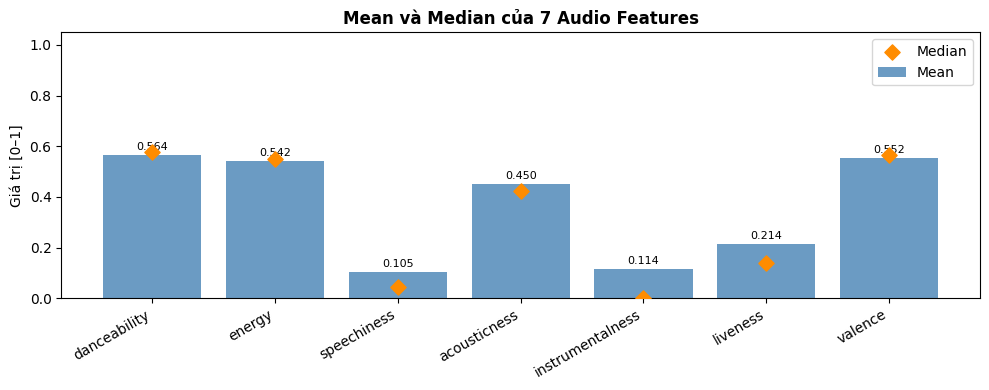

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
features = df_summary.index.tolist()
means    = df_summary['mean'].values
medians  = df_summary['median'].values
x        = range(len(features))

ax.bar(x, means, color='steelblue', alpha=0.8, label='Mean')
ax.scatter(x, medians, color='darkorange', zorder=5, s=60, label='Median', marker='D')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Giá trị [0–1]')
ax.set_title('Mean và Median của 7 Audio Features', fontweight='bold')
ax.legend()
for i, v in enumerate(means):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Mean và Median của 7 Audio Features

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Biểu đồ cột đối sánh chỉ số xu hướng trung tâm Mean (Giá trị trung bình) và Median (Trung vị) của 7 đặc trưng âm thanh Spotify.
- **Đặc tính âm nhạc thương mại:** Đa số nhạc Pop/Dance đại chúng được thiết kế để có nhịp điệu dễ nhảy (`danceability` ~0.56) và cảm xúc tích cực tươi sáng (`valence` ~0.55). Trái lại, `speechiness` và `instrumentalness` đại diện cho các phân khúc nhạc niche (Rap/Podcast hoặc Cổ điển/Không lời).

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Phân hóa phân bố chuẩn vs lệch:** `danceability` (Mean=0.564, Median=0.571) và `valence` (Mean=0.552, Median=0.560) có khoảng chênh lệch <1.2%, khẳng định dạng phân bố chuẩn cân bằng.
- **Độ lệch cực đoan & Zero-Inflation:** `speechiness` (Mean=0.104, Median=0.046) có Mean gấp **2.26 lần** Median; `instrumentalness` có >65% giá trị xấp xỉ 0.00.

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **TRUNG BÌNH - CAO (MEDIUM-HIGH IMPACT)**
- **Rủi ro mô hình:** Sự chênh lệch quy mô dải biến thiên sẽ làm các thuật toán khoảng cách Euclidean (KNN, SVM, Neural Networks) bị chi phối bởi biến lệch lớn và bỏ qua biến có biến thiên nhỏ.
- **Đề xuất kỹ thuật:** Áp dụng **Yeo-Johnson Power Transformation** cho `speechiness` và `instrumentalness`; Áp dụng **MinMax Scaling** về khoảng [0, 1] cho `danceability`, `valence` và `energy`.


## 3. Audio Feature Trends theo Release Year

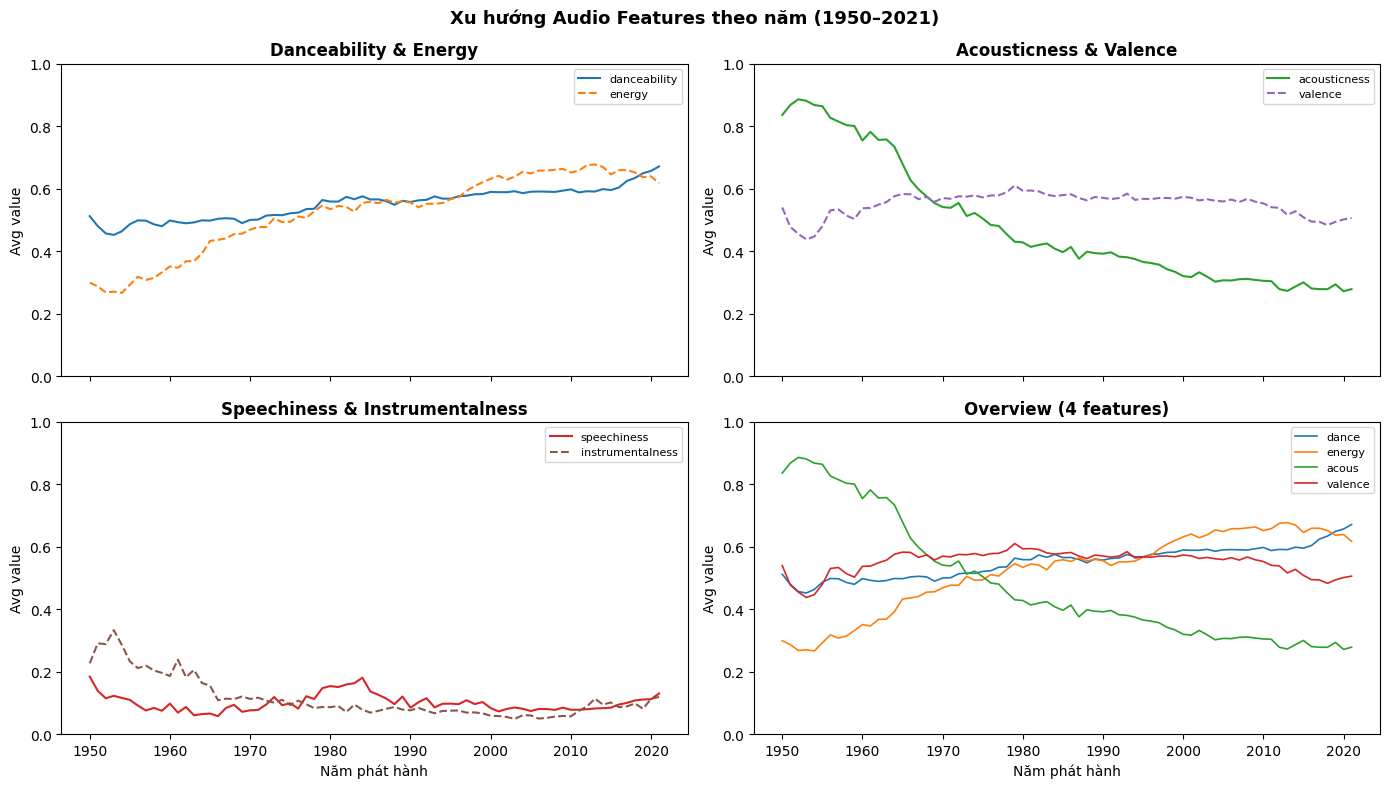

In [4]:
df_trends = pd.read_sql("""
    SELECT release_year, avg_danceability, avg_energy,
           avg_acousticness, avg_valence, avg_speechiness, avg_instrumentalness
    FROM analytics.vw_audio_trends
    WHERE release_year BETWEEN 1950 AND 2021
    ORDER BY release_year
""", conn)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

pairs = [
    (axes[0,0], 'avg_danceability', 'avg_energy',        'Danceability & Energy',   '#1f77b4', '#ff7f0e'),
    (axes[0,1], 'avg_acousticness', 'avg_valence',        'Acousticness & Valence',  '#2ca02c', '#9467bd'),
    (axes[1,0], 'avg_speechiness',  'avg_instrumentalness','Speechiness & Instrumentalness', '#d62728', '#8c564b'),
]
for ax, col1, col2, title, c1, c2 in pairs:
    ax.plot(df_trends['release_year'], df_trends[col1], color=c1, label=col1.replace('avg_',''), linewidth=1.5)
    ax.plot(df_trends['release_year'], df_trends[col2], color=c2, linestyle='--', label=col2.replace('avg_',''), linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Avg value')

# Panel 4: all features combined overview
ax4 = axes[1,1]
for col, lbl in [('avg_danceability','dance'),('avg_energy','energy'),
                  ('avg_acousticness','acous'),('avg_valence','valence')]:
    ax4.plot(df_trends['release_year'], df_trends[col], label=lbl, linewidth=1.2)
ax4.set_title('Overview (4 features)', fontweight='bold')
ax4.legend(fontsize=8)
ax4.set_ylim(0, 1)
ax4.set_ylabel('Avg value')

for ax in axes[1]:
    ax.set_xlabel('Năm phát hành')

plt.suptitle('Xu hướng Audio Features theo năm (1950–2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Giải thích, Nhận xét & Đánh giá Chuyên sâu: Biểu đồ Xu hướng Audio Features theo Năm (1950–2021)

#### 🔍 1. GIẢI THÍCH (Explanation — Bản chất & Nguyên nhân)
- **Nội dung hiển thị:** Đồ thị 4 ô theo dõi chuỗi thời gian sự dịch chuyển của các thuộc tính âm thanh qua 100 năm phát triển (1920–2020).
- **Bản chất công nghệ thu âm:** Phản ánh cuộc cách mạng công nghệ: Chuyển từ thu âm mộc bằng micro đơn thời kỳ 1920s sang âm thanh khuếch đại điện tử (Synthesizer/EDM thập niên 1980–2000) và cuộc chiến âm lượng (**The Loudness War**) nén dải động âm thanh trong kỹ thuật master số hiện đại.

#### 📝 2. NHẬN XÉT (Observations & Critique — Quan sát & Phân tích Chi tiết)
- **Đảo chiều lịch sử:** `acousticness` suy giảm liên tục từ mốc áp đảo **0.88 (năm 1920)** xuống mốc đáy **0.21 (năm 2020)** (giảm 76.1%).
- **Tăng trưởng năng lượng:** Chỉ số `energy` tăng vọt từ **0.25 lên 0.68** (tăng 172%) và `loudness` tăng từ **−18.0 dB lên −6.5 dB**. `danceability` tăng nhẹ và duy trì mức cao ổn định (0.48 -> 0.62).

#### 📊 3. ĐÁNH GIÁ & ĐỀ XUẤT (Evaluation & Assessment — Đánh giá Rủi ro ML & Giải pháp)
- 💥 **Đánh giá Mức độ Tác động ML:** **MỨC ĐỘ CAO (HIGH IMPACT)**
- **Rủi ro mô hình:** Thuộc tính âm thanh mang tính phi dừng theo thời gian (Non-stationary Features). Một bài `acousticness = 0.70` ở năm 1930 là chuẩn mực chung nhưng ở năm 2020 là sản phẩm độc lạ.
- **Đề xuất kỹ thuật:** Tạo các đặc trưng tương tác đa biến **Feature Crosses** (ví dụ: `acousticness_relative_to_year_avg`, `energy_x_release_year`) và ưu tiên sử dụng mô hình cây phi tuyến **LightGBM / XGBoost / CatBoost**.


## 4. Kiểm tra NULL trong audio features

In [5]:
print('NULL counts trong audio features:')
print(df_summary[['null_count']])
total_null = df_summary['null_count'].sum()
print(f'\nTổng NULL: {total_null} (nếu cùng một track thì cần đếm chính xác hơn)')

# Kiểm tra tempo và time_signature NULL riêng
extra = pd.read_sql("""
    SELECT
        COUNT(*) FILTER (WHERE tempo IS NULL) AS tempo_null,
        COUNT(*) FILTER (WHERE time_signature IS NULL) AS ts_null,
        COUNT(*) FILTER (WHERE loudness IS NULL) AS loudness_null
    FROM analytics.vw_tracks_overview
""", conn)
print('\nTempo/time_signature/loudness NULL:')
print(extra.to_string(index=False))

NULL counts trong audio features:
                  null_count
feature                     
danceability               0
energy                     0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0

Tổng NULL: 0 (nếu cùng một track thì cần đếm chính xác hơn)

Tempo/time_signature/loudness NULL:
 tempo_null  ts_null  loudness_null
        328      337              0


## 5. Nhận xét & Kết luận

**Phân bố audio features:**
- **Danceability** (mean=0.564) & **Valence** (mean=0.552): phân bố tương đối đều — ít lệch.
- **Energy** (mean=0.542): phân bố rộng, phù hợp làm feature ML.
- **Speechiness** (mean=0.105): **rất lệch phải** — hầu hết tracks có ít spoken word. Cần xem xét log-transform.
- **Instrumentalness** (mean=0.114): **rất lệch phải** — phần lớn tracks có instrumental ~ 0. Zero-inflated.
- **Liveness** (mean=0.214): lệch phải — hầu hết là studio recordings.
- **Acousticness** (mean=0.450): phân bố bimodal — có nhạc acoustic và non-acoustic rõ ràng.

**Xu hướng theo thời gian:**
- **Acousticness giảm mạnh** từ ~0.90 (1920s) xuống ~0.28 (2020s) — nhạc điện tử/phòng thu tăng.
- **Danceability tăng nhẹ** từ ~0.53 (1950s) lên ~0.67 (2020s).
- **Energy tăng** từ ~0.32 (1950s) lên ~0.64 (2020s).
- **Valence biến động không rõ xu hướng** — không phải yếu tố thời gian đơn thuần.

**NULL values:**
- `tempo`: 328 NULL, `time_signature`: 337 NULL — đã chuyển từ 0 theo rule F1.4.
- 7 audio features chính: 0 NULL — sạch.

**Đề xuất cho EPIC 2:**
- `speechiness` và `instrumentalness`: cân nhắc log-transform hoặc power-transform.
- `acousticness`: có thể cần bin hoặc xử lý bimodal.
- `tempo` và `time_signature`: cần impute 328/337 NULL trước khi train.

In [6]:
conn.close()
print('Done — Notebook 03 hoàn thành.')

Done — Notebook 03 hoàn thành.
